# Week 3: LSTM Deep Learning Model in Google Colab

## Project: Sentiment Classification of Tweets Using Deep Learning

In this notebook, I train the main deep learning model for tweet sentiment classification.

The data preprocessing, text cleaning, label conversion, and train/validation/test split were already completed in Week 2.  
Therefore, this notebook does not repeat Week 1 and Week 2 steps.

This notebook uses the processed files from Week 2:

- `week02_train.csv`
- `week02_val.csv`
- `week02_test.csv`
- `week02_baseline_results.csv`

The main goals of Week 3 are:

- load processed train, validation, and test data;
- build vocabulary from the training data only;
- convert tweet text into integer sequences;
- create PyTorch Dataset and DataLoader objects;
- build an LSTM model;
- train the LSTM model;
- evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix;
- compare LSTM with the Week 2 baseline model.

Task type: Binary text classification

Classes:

- `0` = negative
- `1` = positive

In [9]:
# Import libraries for Week 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
from pathlib import Path
from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)

Libraries imported successfully.
PyTorch version: 2.10.0+cpu


## 1. Check Uploaded Files in Colab

All Week 2 files were uploaded separately to Colab.

In Colab, uploaded files are usually stored in the current folder `/content`.

This step checks if the required files exist.

In [19]:
# Work directly with uploaded files in Colab current folder

CURRENT_DIR = Path.cwd()

print("Current Colab folder:")
print(CURRENT_DIR)

print("\nFiles in current folder:")
for file in CURRENT_DIR.iterdir():
    print("-", file.name)


def find_uploaded_file(filename):
    """
    Finds uploaded file in the current Colab folder.
    If exact filename is not found, it tries to find files like:
    week02_train (1).csv, week02_train-1.csv, etc.
    """
    exact_path = CURRENT_DIR / filename

    if exact_path.exists():
        return exact_path

    name_without_ext = filename.replace(".csv", "")
    matches = list(CURRENT_DIR.glob(f"{name_without_ext}*.csv"))

    if len(matches) > 0:
        print(f"Exact file {filename} was not found.")
        print(f"Using found file instead: {matches[0].name}")
        return matches[0]

    raise FileNotFoundError(f"{filename} was not found in Colab current folder.")


train_path = find_uploaded_file("week02_train.csv")
val_path = find_uploaded_file("week02_val.csv")
test_path = find_uploaded_file("week02_test.csv")
baseline_path = find_uploaded_file("week02_baseline_results.csv")

print("\nFiles found successfully:")
print("Train:", train_path)
print("Validation:", val_path)
print("Test:", test_path)
print("Baseline:", baseline_path)

Current Colab folder:
/content

Files in current folder:
- .config
- training.1600000.processed.noemoticon (3).csv
- week02_train.csv
- week02_test.csv
- .ipynb_checkpoints
- week02_val.csv
- week02_baseline_results.csv
- sample_data

Files found successfully:
Train: /content/week02_train.csv
Validation: /content/week02_val.csv
Test: /content/week02_test.csv
Baseline: /content/week02_baseline_results.csv


## 2. Load Processed Data from Week 2

This step loads the already prepared train, validation, and test files.

Each file contains:

- `clean_text` — cleaned tweet text;
- `label` — sentiment label.

In [20]:
# Load uploaded Week 2 processed data directly

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (159998, 2)
Validation shape: (20000, 2)
Test shape: (20000, 2)


,clean_text,label
0,have bad conscience my gift for my mom wasn't ...,0
1,some slogging can even take them to pakcricket,0
2,okay this kinda cheered me up lol,1
3,user yea i landed it a while ago like havn't b...,0
4,i have a new blog post for all you victims,1


In [21]:
# Check columns and missing values

print("Train columns:", train_df.columns.tolist())
print("Validation columns:", val_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

print("\nMissing values in train:")
print(train_df.isnull().sum())

print("\nMissing values in validation:")
print(val_df.isnull().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum())

Train columns: ['clean_text', 'label']
Validation columns: ['clean_text', 'label']
Test columns: ['clean_text', 'label']

Missing values in train:
clean_text    0
label         0
dtype: int64

Missing values in validation:
clean_text    0
label         0
dtype: int64

Missing values in test:
clean_text    0
label         0
dtype: int64


In [22]:
# Remove possible missing rows

train_df = train_df.dropna(subset=["clean_text", "label"]).copy()
val_df = val_df.dropna(subset=["clean_text", "label"]).copy()
test_df = test_df.dropna(subset=["clean_text", "label"]).copy()

train_df["clean_text"] = train_df["clean_text"].astype(str)
val_df["clean_text"] = val_df["clean_text"].astype(str)
test_df["clean_text"] = test_df["clean_text"].astype(str)

train_df["label"] = train_df["label"].astype(int)
val_df["label"] = val_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

print("After removing missing values:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

After removing missing values:
Train: (159998, 2)
Validation: (20000, 2)
Test: (20000, 2)


In [23]:
# Check label distribution

print("Train label distribution:")
print(train_df["label"].value_counts())

print("\nValidation label distribution:")
print(val_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train label distribution:
label
0    79999
1    79999
Name: count, dtype: int64

Validation label distribution:
label
1    10000
0    10000
Name: count, dtype: int64

Test label distribution:
label
0    10000
1    10000
Name: count, dtype: int64


## 3. Tokenization and Vocabulary

The LSTM model cannot directly process raw text.

Therefore, each tweet is tokenized into words.  
Then a vocabulary is built from the training set only.

This prevents data leakage because validation and test sets are not used for vocabulary creation.

In [24]:
# Simple tokenizer

def tokenize(text):
    return re.findall(r"[a-z']+", str(text).lower())


# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

PAD_IDX = 0
UNK_IDX = 1

MAX_VOCAB_SIZE = 30000
MIN_FREQ = 2

# Build vocabulary from training data only
counter = Counter()

for text in train_df["clean_text"].tolist():
    counter.update(tokenize(text))

most_common_words = [
    word
    for word, freq in counter.most_common(MAX_VOCAB_SIZE)
    if freq >= MIN_FREQ
]

itos = [PAD_TOKEN, UNK_TOKEN] + most_common_words
stoi = {word: idx for idx, word in enumerate(itos)}

print("Vocabulary size:", len(itos))
print("\nMost common words:")
print(counter.most_common(20))

Vocabulary size: 29263

Most common words:
[('user', 78777), ('i', 77396), ('to', 56552), ('the', 52046), ('a', 38692), ('my', 32137), ('and', 30539), ('you', 27429), ('it', 23659), ('is', 23258), ('for', 21688), ('in', 21499), ('of', 18518), ('on', 16946), ('me', 16206), ('so', 15300), ('have', 14405), ('that', 14276), ('but', 13507), ("i'm", 13164)]


## 4. Convert Text into Sequences

Each tweet is converted into a sequence of word IDs.

Long tweets are truncated.  
Short tweets are padded with `<PAD>` tokens.

This is required because neural networks process data in fixed-size mini-batches.

In [25]:
# Convert text to sequence of word IDs

MAX_LEN = 40

def encode_text(text, stoi, max_len=MAX_LEN):
    tokens = tokenize(text)

    ids = [
        stoi.get(token, UNK_IDX)
        for token in tokens
    ]

    # Truncate long sequences
    ids = ids[:max_len]

    # Pad short sequences
    if len(ids) < max_len:
        ids = ids + [PAD_IDX] * (max_len - len(ids))

    return ids


# Test encoding
example_text = train_df["clean_text"].iloc[0]
example_encoded = encode_text(example_text, stoi)

print("Example text:")
print(example_text)

print("\nEncoded sequence:")
print(example_encoded)

print("\nSequence length:", len(example_encoded))

Example text:
have bad conscience my gift for my mom wasn't terrific

Encoded sequence:
[18, 109, 13985, 7, 1517, 12, 7, 319, 498, 7767, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Sequence length: 40


## 5. PyTorch Dataset and DataLoader

PyTorch Dataset stores encoded tweet sequences and labels.

DataLoader creates mini-batches for training, validation, and testing.

In [26]:
# PyTorch Dataset class

class TweetDataset(Dataset):
    def __init__(self, dataframe, stoi, max_len):
        self.texts = dataframe["clean_text"].astype(str).tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_ids = encode_text(
            self.texts[idx],
            self.stoi,
            self.max_len
        )

        label = self.labels[idx]

        return {
            "input_ids": torch.tensor(text_ids, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.float)
        }


train_dataset = TweetDataset(train_df, stoi, MAX_LEN)
val_dataset = TweetDataset(val_df, stoi, MAX_LEN)
test_dataset = TweetDataset(test_df, stoi, MAX_LEN)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 159998
Validation dataset size: 20000
Test dataset size: 20000


In [27]:
# Create DataLoaders

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

batch = next(iter(train_loader))

print("Batch input shape:", batch["input_ids"].shape)
print("Batch label shape:", batch["label"].shape)

Batch input shape: torch.Size([128, 40])
Batch label shape: torch.Size([128])


## 6. Device Setup

In Google Colab, GPU can be enabled from:

`Runtime → Change runtime type → GPU`

If GPU is available, the model will use GPU.  
Otherwise, it will use CPU.

In [28]:
# Device setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


## 7. LSTM Model Architecture

The LSTM model is the main deep learning model in this project.

The model includes:

- Embedding layer;
- LSTM layer;
- Dropout layer;
- Fully connected output layer.

The embedding layer converts word IDs into dense vectors.  
The LSTM layer processes tweets as sequences and learns context.  
The dropout layer helps reduce overfitting.  
The final layer produces one output value for binary classification.

In [29]:
# LSTM model for binary sentiment classification

class SentimentLSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=100,
        hidden_dim=128,
        output_dim=1,
        num_layers=1,
        dropout=0.3
    ):
        super(SentimentLSTM, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=PAD_IDX
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0 if num_layers == 1 else dropout
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)

        output, (hidden, cell) = self.lstm(embedded)

        final_hidden = hidden[-1]
        final_hidden = self.dropout(final_hidden)

        logits = self.fc(final_hidden)

        return logits.squeeze(1)

## 8. Training and Evaluation Functions

The training function updates model weights using the training set.

The evaluation function calculates:

- loss;
- accuracy;
- precision;
- recall;
- F1-score.

In [30]:
# Training function

def train_one_epoch(model, data_loader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)

    return avg_loss


# Evaluation function

def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            total_loss += loss.item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(data_loader)

    all_labels = np.array(all_labels).astype(int)
    all_preds = np.array(all_preds).astype(int)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_preds
    }

## 9. Create LSTM Model

The LSTM model is created with:

- embedding dimension: 100;
- hidden dimension: 128;
- dropout: 0.3;
- loss function: Binary Cross-Entropy with Logits;
- optimizer: Adam.

In [31]:
# Create LSTM model

lstm_model = SentimentLSTM(
    vocab_size=len(itos),
    embedding_dim=100,
    hidden_dim=128,
    output_dim=1,
    num_layers=1,
    dropout=0.3
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

print(lstm_model)

SentimentLSTM(
  (embedding): Embedding(29263, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


## 10. Train LSTM Model

The model is trained for several epochs.

For each epoch, I save:

- training loss;
- validation loss;
- validation accuracy;
- validation F1-score.

In [32]:
# Train LSTM model

EPOCHS = 3

lstm_history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": []
}

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        lstm_model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_results = evaluate_model(
        lstm_model,
        val_loader,
        criterion,
        device
    )

    lstm_history["train_loss"].append(train_loss)
    lstm_history["val_loss"].append(val_results["loss"])
    lstm_history["val_accuracy"].append(val_results["accuracy"])
    lstm_history["val_f1"].append(val_results["f1"])

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("Train Loss:", round(train_loss, 4))
    print("Validation Loss:", round(val_results["loss"], 4))
    print("Validation Accuracy:", round(val_results["accuracy"], 4))
    print("Validation F1:", round(val_results["f1"], 4))
    print("-" * 50)

Epoch 1/3
Train Loss: 0.6934
Validation Loss: 0.6932
Validation Accuracy: 0.5
Validation F1: 0.0
--------------------------------------------------
Epoch 2/3
Train Loss: 0.6934
Validation Loss: 0.6931
Validation Accuracy: 0.5
Validation F1: 0.6667
--------------------------------------------------
Epoch 3/3
Train Loss: 0.6931
Validation Loss: 0.6739
Validation Accuracy: 0.5806
Validation F1: 0.3878
--------------------------------------------------


## 11. Training Plots

The plots show how the model learned during training.

The loss plot shows training and validation loss.  
The accuracy and F1-score plots show validation performance.

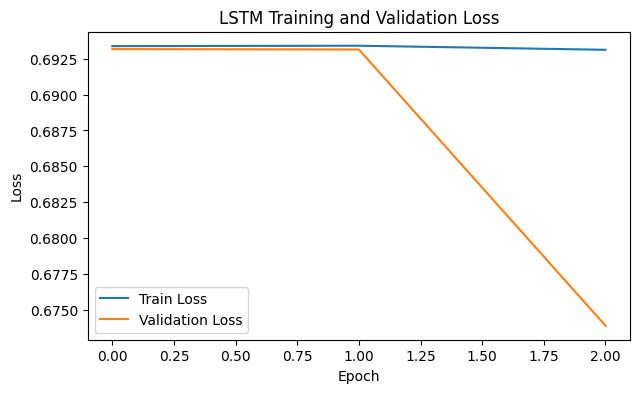

In [33]:
# Plot training and validation loss

plt.figure(figsize=(7, 4))
plt.plot(lstm_history["train_loss"], label="Train Loss")
plt.plot(lstm_history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

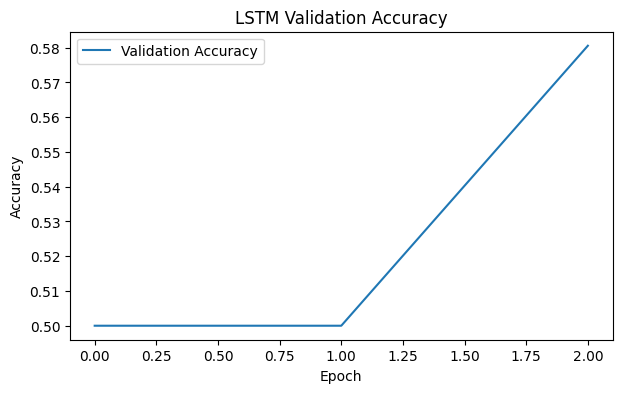

In [34]:
# Plot validation accuracy

plt.figure(figsize=(7, 4))
plt.plot(lstm_history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

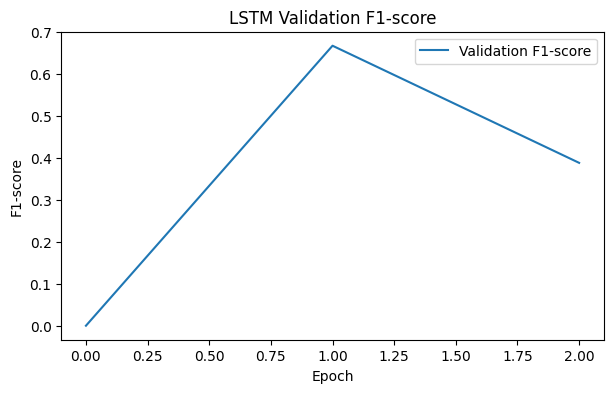

In [35]:
# Plot validation F1-score

plt.figure(figsize=(7, 4))
plt.plot(lstm_history["val_f1"], label="Validation F1-score")
plt.title("LSTM Validation F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.show()

## 12. Test Evaluation

The test set is used for final LSTM evaluation.

The model has not seen test examples during training.

In [36]:
# Evaluate LSTM on test set

lstm_test_results = evaluate_model(
    lstm_model,
    test_loader,
    criterion,
    device
)

print("LSTM Test Results")
print("-----------------")
print("Test Loss:", round(lstm_test_results["loss"], 4))
print("Accuracy:", round(lstm_test_results["accuracy"], 4))
print("Precision:", round(lstm_test_results["precision"], 4))
print("Recall:", round(lstm_test_results["recall"], 4))
print("F1-score:", round(lstm_test_results["f1"], 4))

print("\nClassification Report:")
print(
    classification_report(
        lstm_test_results["labels"],
        lstm_test_results["predictions"],
        target_names=["negative", "positive"],
        zero_division=0
    )
)

LSTM Test Results
-----------------
Test Loss: 0.6723
Accuracy: 0.5841
Precision: 0.7224
Recall: 0.2732
F1-score: 0.3965

Classification Report:
              precision    recall  f1-score   support

    negative       0.55      0.90      0.68     10000
    positive       0.72      0.27      0.40     10000

    accuracy                           0.58     20000
   macro avg       0.64      0.58      0.54     20000
weighted avg       0.64      0.58      0.54     20000



## 13. Confusion Matrix

The confusion matrix shows correct and incorrect predictions for negative and positive classes.

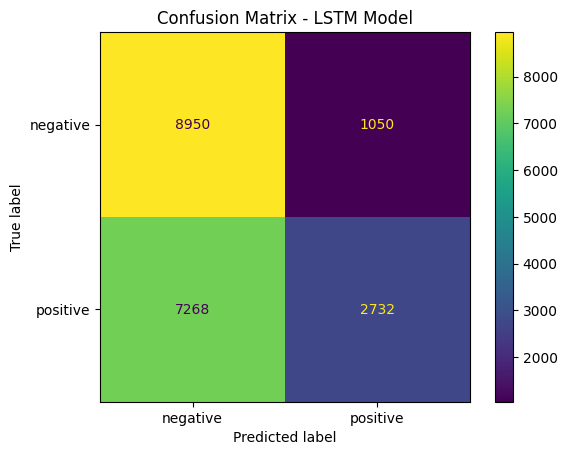

In [37]:
# Plot LSTM confusion matrix

cm = confusion_matrix(
    lstm_test_results["labels"],
    lstm_test_results["predictions"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - LSTM Model")
plt.show()

## 14. Compare Baseline and LSTM

The Week 2 baseline model was:

- Logistic Regression + TF-IDF

The Week 3 deep learning model is:

- LSTM

This section compares both models using the same metrics.

In [38]:
# Create LSTM results table

lstm_results_table = pd.DataFrame([
    {
        "model": "LSTM",
        "test_accuracy": lstm_test_results["accuracy"],
        "test_precision": lstm_test_results["precision"],
        "test_recall": lstm_test_results["recall"],
        "test_f1": lstm_test_results["f1"],
        "test_loss": lstm_test_results["loss"]
    }
])

# Load Week 2 baseline results directly from uploaded file
baseline_results = pd.read_csv(baseline_path)

baseline_row = pd.DataFrame([
    {
        "model": "Logistic Regression + TF-IDF",
        "test_accuracy": baseline_results.loc[0, "test_accuracy"],
        "test_precision": baseline_results.loc[0, "test_precision"],
        "test_recall": baseline_results.loc[0, "test_recall"],
        "test_f1": baseline_results.loc[0, "test_f1"],
        "test_loss": np.nan
    }
])

comparison_results = pd.concat(
    [baseline_row, lstm_results_table],
    ignore_index=True
)

comparison_results

,model,test_accuracy,test_precision,test_recall,test_f1,test_loss
0,Logistic Regression + TF-IDF,0.79965,0.794786,0.8079,0.801289,NaN
1,LSTM,0.58410,0.722369,0.2732,0.396459,0.67233


In [39]:
# Save Week 3 results directly in current Colab folder

week03_results_path = CURRENT_DIR / "week03_lstm_results.csv"

comparison_results.to_csv(
    week03_results_path,
    index=False
)

print("Week 3 results saved to:")
print(week03_results_path)

Week 3 results saved to:
/content/week03_lstm_results.csv


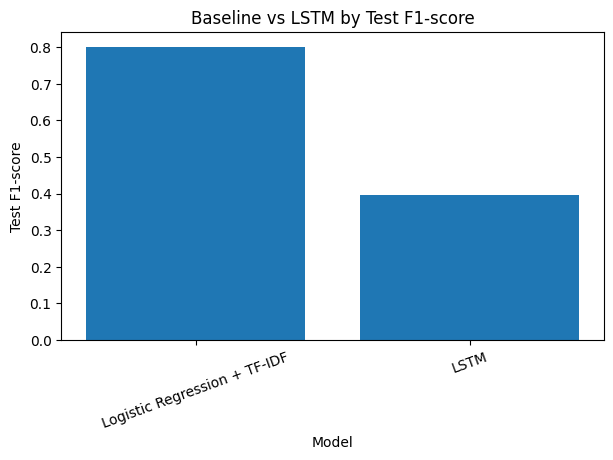

In [40]:
# Plot model comparison by F1-score

plt.figure(figsize=(7, 4))
plt.bar(comparison_results["model"], comparison_results["test_f1"])
plt.title("Baseline vs LSTM by Test F1-score")
plt.xlabel("Model")
plt.ylabel("Test F1-score")
plt.xticks(rotation=20)
plt.show()

## 15. Save LSTM Model and Vocabulary

The trained LSTM model and vocabulary are saved for future use.

They can be reused in Week 4 for final report, final comparison, or demo.

In [41]:
# Save LSTM model and vocabulary directly in current Colab folder

lstm_model_path = CURRENT_DIR / "week03_lstm_model.pt"
vocab_path = CURRENT_DIR / "week03_vocab.json"

torch.save(
    lstm_model.state_dict(),
    lstm_model_path
)

with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(stoi, f, ensure_ascii=False, indent=2)

print("LSTM model saved to:", lstm_model_path)
print("Vocabulary saved to:", vocab_path)

LSTM model saved to: /content/week03_lstm_model.pt
Vocabulary saved to: /content/week03_vocab.json


## 16. Error Analysis

In this section, I inspect examples where the LSTM model made wrong predictions.

This helps to understand model limitations.

In [42]:
# Create error analysis dataframe

lstm_error_df = pd.DataFrame({
    "text": test_df["clean_text"].values,
    "true_label": lstm_test_results["labels"],
    "predicted_label": lstm_test_results["predictions"]
})

lstm_error_df["true_sentiment"] = lstm_error_df["true_label"].map({
    0: "negative",
    1: "positive"
})

lstm_error_df["predicted_sentiment"] = lstm_error_df["predicted_label"].map({
    0: "negative",
    1: "positive"
})

lstm_wrong = lstm_error_df[
    lstm_error_df["true_label"] != lstm_error_df["predicted_label"]
]

print("Number of wrong LSTM predictions:", len(lstm_wrong))
print("Total test examples:", len(lstm_error_df))

lstm_wrong.head(10)

Number of wrong LSTM predictions: 8318
Total test examples: 20000


,text,true_label,predicted_label,true_sentiment,predicted_sentiment
3,enjoying a coffee with my bro at l'esspresso r...,1,0,positive,negative
4,cooking noodles no lunch l,1,0,positive,negative
7,user yay i'm hot,1,0,positive,negative
8,hoping user busts a dance move in steps or les...,1,0,positive,negative
10,stressful exam is coming oh noooo,0,1,negative,positive
13,user blackberry bolds and javelins now in stoc...,1,0,positive,negative
14,ha ha 'flight of the concords' cracks me up,1,0,positive,negative
17,tickets for koncerthuset on friday with coyb i...,1,0,positive,negative
18,user heey girls i miss all you so back the cla...,1,0,positive,negative
20,user good luck too bad india missed it by meas...,0,1,negative,positive


In [43]:
# Show several wrong LSTM predictions

for i, row in lstm_wrong.sample(
    n=min(10, len(lstm_wrong)),
    random_state=42
).iterrows():
    print("Tweet:", row["text"])
    print("True label:", row["true_sentiment"])
    print("Predicted label:", row["predicted_sentiment"])
    print("-" * 80)

Tweet: user dude i tweeted that an hour ago
True label: positive
Predicted label: negative
--------------------------------------------------------------------------------
Tweet: hm i just went on my home on myspace saw my default i'm pretty cute
True label: positive
Predicted label: negative
--------------------------------------------------------------------------------
Tweet: feeling much better today some baking might occur just to finish up the weekend
True label: positive
Predicted label: negative
--------------------------------------------------------------------------------
Tweet: ah rain is brutal headache naaaap
True label: negative
Predicted label: positive
--------------------------------------------------------------------------------
Tweet: dang i missed sum tweets thank u to all my ppl who ff me i love yall too i'll do mine later i gotta dye this hair
True label: positive
Predicted label: negative
-------------------------------------------------------------------------

## 17. Download Week 3 Results from Colab

This step downloads the Week 3 result files from Colab to the computer.

Download these files and add them to the GitHub repository:

- `week03_lstm_results.csv`
- `week03_lstm_model.pt`
- `week03_vocab.json`

In [44]:
# Download Week 3 result files from Colab

from google.colab import files

files.download(str(week03_results_path))
files.download(str(lstm_model_path))
files.download(str(vocab_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. Week 3 Conclusion

During Week 3, I trained the main deep learning model for this project.

The LSTM model was implemented using PyTorch.  
The model used processed data from Week 2, so data loading, cleaning, and splitting were not repeated.

The LSTM model was evaluated using:

- accuracy;
- precision;
- recall;
- F1-score;
- confusion matrix.

The LSTM result was saved and compared with the Week 2 baseline model.  
In Week 4, I will complete the final comparison, final report, and presentation.